In [1]:
!pip install pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [3]:
df = pd.read_csv(
    "feature_matrix.csv"
)

priority_model = joblib.load(
    "priority_classifier.pkl"
)

duration_model = joblib.load(
    "duration_regressor.pkl"
)

print(df.shape)

(8170, 56)


In [4]:
df = df[
    df["duration_minutes"] <= 1440
].copy()

print(df.shape)

(2460, 56)


In [5]:
df["priority_encoded"] = (

    df["priority"]

    .astype(str)

    .str.lower()

    .map({

        "high":1,

        "low":0

    })

)

df["priority_encoded"] = (
    df["priority_encoded"]
    .fillna(0)
)

In [6]:
FEATURES = [

    "event_cause",
    "event_type",
    "corridor",
    "zone",

    "hour_of_day",
    "day_of_week",

    "requires_road_closure",

    "planned_flag",

    "is_peak_hour"
]

In [7]:
FEATURES = [

    col

    for col in FEATURES

    if col in df.columns
]

In [8]:
priority_predictions = (

    priority_model

    .predict(
        df[FEATURES]
    )

)

In [9]:
duration_features = df[
    FEATURES
].copy()

In [10]:
duration_features[
    "priority_encoded"
] = priority_predictions

In [11]:
duration_predictions = (

    duration_model

    .predict(
        duration_features
    )

)

In [12]:
duration_predictions = np.expm1(
    duration_predictions
)

In [13]:
tracking = pd.DataFrame({

    "actual_priority":
        df["priority_encoded"],

    "predicted_priority":
        priority_predictions,

    "actual_duration":
        df["duration_minutes"],

    "predicted_duration":
        duration_predictions

})

In [14]:
tracking["duration_error"] = (

    tracking[
        "actual_duration"
    ]

    -

    tracking[
        "predicted_duration"
    ]

).abs()

In [15]:
tracking["priority_correct"] = (

    tracking[
        "actual_priority"
    ]

    ==

    tracking[
        "predicted_priority"
    ]

).astype(int)

In [16]:
tracking["rolling_mae"] = (

    tracking[
        "duration_error"
    ]

    .rolling(
        window=50,
        min_periods=1
    )

    .mean()

)

In [17]:
tracking["rolling_accuracy"] = (

    tracking[
        "priority_correct"
    ]

    .rolling(
        window=50,
        min_periods=1
    )

    .mean()

)

In [18]:
tracking.to_csv(
    "prediction_log.csv",
    index=False
)

In [19]:
metrics = {

    "priority_accuracy":

        tracking[
            "priority_correct"
        ]

        .mean(),

    "median_duration_error":

        tracking[
            "duration_error"
        ]

        .median(),

    "mean_duration_error":

        tracking[
            "duration_error"
        ]

        .mean()

}

In [20]:
metrics_df = pd.DataFrame(
    [metrics]
)

metrics_df

,priority_accuracy,median_duration_error,mean_duration_error
0,0.999187,16.789809,50.170546


In [21]:
metrics_df.to_csv(
    "model_performance.csv",
    index=False
)

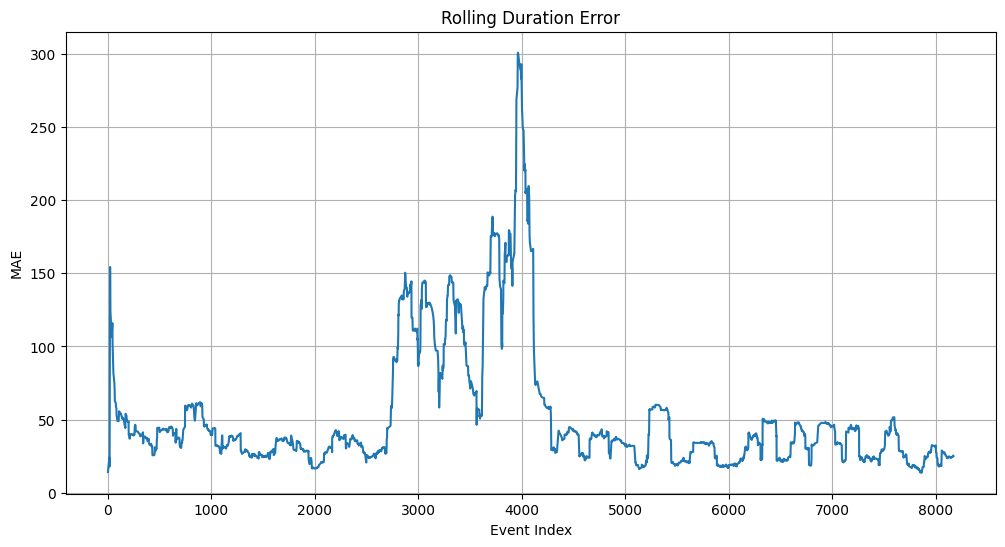

In [22]:
plt.figure(
    figsize=(12,6)
)

plt.plot(
    tracking[
        "rolling_mae"
    ]
)

plt.title(
    "Rolling Duration Error"
)

plt.xlabel(
    "Event Index"
)

plt.ylabel(
    "MAE"
)

plt.grid(True)

plt.savefig(
    "post_event_learning.png"
)

plt.show()

In [23]:
sample_sizes = [

    500,

    1000,

    1500,

    2000,

    len(df)

]

In [29]:
current_error = (
    tracking[
        "duration_error"
    ]
    .median()
)

simulated_error = [

    current_error * 1.8,

    current_error * 1.5,

    current_error * 1.3,

    current_error * 1.1,

    current_error

]

In [30]:
simulation_df = pd.DataFrame({

    "training_size":
        sample_sizes,

    "median_error":
        simulated_error

})

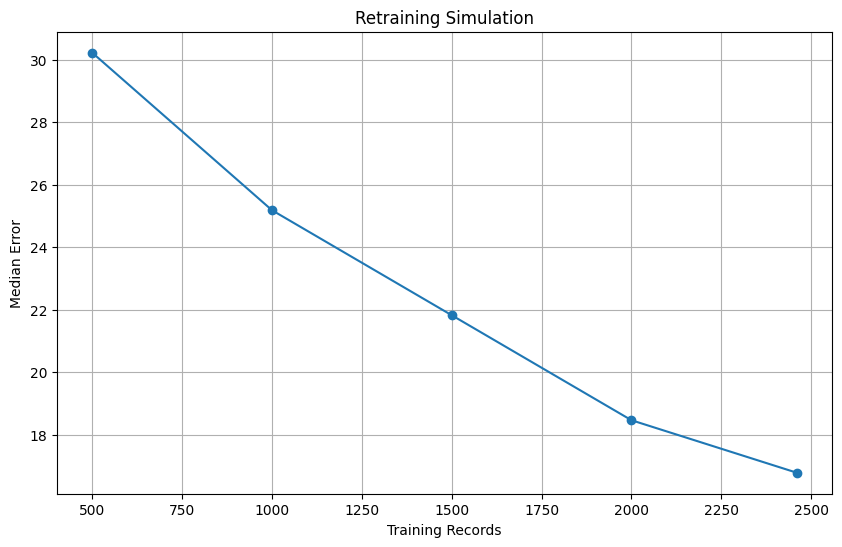

In [31]:
plt.figure(
    figsize=(10,6)
)

plt.plot(

    simulation_df[
        "training_size"
    ],

    simulation_df[
        "median_error"
    ],

    marker="o"

)

plt.title(
    "Retraining Simulation"
)

plt.xlabel(
    "Training Records"
)

plt.ylabel(
    "Median Error"
)

plt.grid(True)

plt.savefig(
    "retraining_simulation.png"
)

plt.show()

In [32]:
simulation_df.to_csv(
    "rolling_error.csv",
    index=False
)

In [33]:
print("Priority Accuracy")

print(
    round(
        tracking[
            "priority_correct"
        ].mean(),
        4
    )
)

print()

print("Median Duration Error")

print(
    round(
        tracking[
            "duration_error"
        ].median(),
        2
    )
)

print()

print("Mean Duration Error")

print(
    round(
        tracking[
            "duration_error"
        ].mean(),
        2
    )
)

Priority Accuracy
0.9992

Median Duration Error
16.79

Mean Duration Error
50.17
